<a href="https://colab.research.google.com/github/yulia3006/ml-basics/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%96%2012.2_%D0%93%D0%B5%D0%BE%D0%BC%D0%B0%D1%80%D0%BA%D0%B5%D1%82%D0%B8%D0%BD%D0%B3%D0%BE%D0%B2%D0%BE%D0%B5_%D0%B8%D1%81%D1%81%D0%BB%D0%B5%D0%B4%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5_%D1%82%D0%B5%D1%80%D1%80%D0%B8%D1%82%D0%BE%D1%80%D0%B8%D0%B9_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа. Геомаркетинговое исследование территорий с применением методов машинного обучения**


## **Цель работы**


Овладеть методами пространственного анализа и машинного обучения для решения практической задачи определения оптимальных локаций размещения коммерческих объектов.

## **Введение**


В современном бизнесе местоположение коммерческого объекта играет ключевую роль в его успешности. Геомаркетинговый анализ позволяет объективно оценить привлекательность различных локаций, опираясь на количественные показатели и алгоритмы машинного обучения.

В рамках данной работы вы примените полный цикл пространственного анализа, включая сбор данных из открытых источников, обработку и агрегацию пространственной информации, обучение моделей машинного обучения и визуализацию результатов.

## **Задание**


Провести геомаркетинговое исследование для выбора оптимальных локаций размещения новых точек определенного типа бизнеса на территории выбранного города.

## **Порядок выполнения работы**

### **Часть 1. Подготовка данных и определение задачи**



1. **Индивидуальный выбор территории и типа бизнеса**:
   - Выберите город/район для проведения анализа (например, центральная часть Москвы, Санкт-Петербурга или любого другого крупного города)
   - Определите тип бизнеса для анализа (аптеки, продуктовые магазины, пункты выдачи заказов, рестораны определенной кухни и т.д.)
   - Обоснуйте свой выбор: почему данная территория и тип бизнеса интересны для анализа?

2. **Определение ключевых факторов успешности**:
   - Самостоятельно сформулируйте не менее 5 факторов, которые могут влиять на успешность выбранного типа бизнеса
   - Для каждого фактора определите, какими данными из OpenStreetMap его можно количественно описать
   - Составьте таблицу соответствия между факторами и тегами OpenStreetMap

3. **Сбор исходных данных**:
   - Настройте необходимые библиотеки из теоретического материала
   - Определите необходимую область интереса (ROI) с помощью интерактивной карты
   - Загрузите данные о существующих объектах вашего типа бизнеса и объектах инфраструктуры, связанных с выделенными вами факторами

In [ ]:
пункт 1
Территория: г. Александров, Владимирская область
Тип бизнеса: Пункты выдачи заказов (ПВЗ) маркетплейсов и логистических операторов (Wildberries, Ozon, Яндекс.Маркет, СДЭК и др.)
Обоснование выбора:
Почему выбран г. Александров и ПВЗ?
1. Город:  мой родной город+население ~55 тыс. человек достаточно для анализа, но не перегружает вычисления.
Есть чёткое деление: исторический центр + новые жилые районы, разная плотность людей и трафика.
2. Бизнес (пункты выдачи заказов):
Успех ПВЗ сильно зависит от места: чем ближе к людям и удобнее подъезд, тем выше спрос.
Важно избегать мест, где уже много конкурентов в шаговой доступности.
3. Удобство для учебной работы:
Город компактный, данные из OSM загружаются быстро.
Есть дороги, жилые дома, магазины, можно отработать все этапы: от сбора данных до построения прогнозной модели.

In [ ]:
пункт 2
№ |                Фактор успешности ПВЗ         | Количественная метрика                               | Соответствующие теги OpenStreetMap
1 | Плотность жилого фонда (потенциальный спрос) | Количество жилых зданий/блоков в радиусе 500 м       | building=residential, building=apartments, landuse=residential
2 |                Транспортная доступность      | Длина улично-дорожной сети, наличие остановок ОТ     | highway=* (все типы дорог), public_transport=stop_position, railway=station
3 |                Уровень конкуренции           |  Количество действующих ПВЗ в радиусе 800 м          | shop=parcel_pickup, name~"Wildberries|Ozon|Яндекс|СДЭК"
4 |           Коммерческая активность зоны       |  Наличие супермаркетов, рынков, ТЦ                   | shop=supermarket, amenity=marketplace, shop=mall, landuse=commercial
5 |          Инфраструктура для посетителей      | Наличие парковок, пешеходных зон, фасадная видимость | amenity=parking, highway=pedestrian, building=retail

In [ ]:
!pip install osmnx geopandas pandas numpy leafmap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 667.5/667.5 kB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 108.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.0/74.0 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 99.8 MB/s eta 0:00:00
  Attempting uninstall: duckdb
    Found existing install

In [2]:
!pip install osmnx geopandas leafmap mapclassify h3pandas h3~=3.0
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import leafmap
import osmnx as ox
from shapely.geometry import box, Polygon
from sklearn.preprocessing import MinMaxScaler
import h3
import h3pandas

INFO: pip is looking at multiple versions of h3pandas to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.4/138.4 kB 7.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 667.5/667.5 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 66.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 99.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
m = leafmap.Map(draw_control=True, basemap='CartoDB.Positron')
m

bbox = m.user_roi_bounds()
if bbox:
    print(f"Выбранный bounding box: {bbox}")
else:
    bbox = [38.58, 56.19, 38.84, 38.30]
    print(f" Область не выбрана. Используем значение по умолчанию для г. Александров: {bbox}")

pvz_tags = {
    'shop': ['parcel_pickup', 'outpost', 'convenience'],
    'brand': ['Ozon', 'Wildberries', 'СДЭК', 'Яндекс', 'Boxberry'],
    'name': ['Ozon', 'Wildberries', 'СДЭК', 'Яндекс', 'ПВЗ']
}

try:
    pvz_gdf = ox.features_from_place("Александров, Владимирская область, Россия", tags=pvz_tags)
    pvz_gdf.crs = "EPSG:4326"
    print(f" Найдено объектов ПВЗ: {len(pvz_gdf)}")
except Exception as e:
    print(f"Не удалось загрузить данные по тегам: {e}")
    pvz_gdf = gpd.GeoDataFrame(crs="EPSG:4326")

center_lat = (bbox[1] + bbox[3]) / 2
center_lon = (bbox[0] + bbox[2]) / 2

m2 = leafmap.Map(
    center=[center_lat, center_lon],
    zoom=12,
    basemap='CartoDB.Positron'
)

if not pvz_gdf.empty:
    m2.add_gdf(
        pvz_gdf,
        layer_name='ПВЗ маркетплейсов',
        info_mode='on_click',
        color='red',
        opacity=0.8
    )

m2

 Область не выбрана. Используем значение по умолчанию для г. Александров: [38.58, 56.19, 38.84, 38.3]
 Найдено объектов ПВЗ: 67


Map(center=[47.245, 38.71], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_…

### **Часть 2. Пространственное агрегирование и создание признаков**


1. **Создание гексагональной сетки**:
   - Самостоятельно определите оптимальную детализацию сетки H3 для вашего анализа
   - Обоснуйте выбор разрешения (resolution) сетки с учётом масштаба вашей территории и специфики бизнеса
   - Покройте территорию гексагональной сеткой выбранного разрешения

2. **Инженерия пространственных признаков**:
   - Определите радиусы для анализа ближнего и среднего окружения (могут отличаться от предложенных в теории в зависимости от специфики вашего бизнеса)
   - Разработайте и реализуйте не менее 10 пространственных признаков, описывающих характеристики каждой ячейки
   - **Дополнительное задание**: придумайте и реализуйте не менее 2 пространственных признаков, которых нет в теоретическом материале

3. **Анализ полученных признаков**:
   - Рассчитайте базовую статистику по каждому признаку
   - Исследуйте корреляции между признаками
   - Выявите и обработайте выбросы и пропущенные значения, если они имеются

In [4]:
warnings.filterwarnings('ignore')

bbox_alexandrov = [38.65, 56.22, 38.78, 56.28]
bbox_poly = box(*bbox_alexandrov)

RESOLUTION = 9

h3_indexes = list(h3.polyfill_geojson(bbox_poly.__geo_interface__, RESOLUTION))
h3_geometries = [Polygon(h3.h3_to_geo_boundary(idx, geo_json=True)) for idx in h3_indexes]

h3_grid = gpd.GeoDataFrame(
    {'h3_index': h3_indexes, 'geometry': h3_geometries},
    crs="EPSG:4326"
)

crs_metric = "EPSG:3857"
h3_grid = h3_grid.to_crs(crs_metric)

print(f"Создано H3-ячеек: {len(h3_grid)}")
print(f"Средняя площадь ячейки: {h3_grid.geometry.area.mean() / 1e6:.2f} км²")
h3_grid.head()

Создано H3-ячеек: 537
Средняя площадь ячейки: 0.32 км²


,h3_index,geometry
0,89118cbab17ffff,"POLYGON ((4315175.03 7605591.272, 4315443.394 ..."
1,89118ca34bbffff,"POLYGON ((4315955.444 7613825.16, 4316224.072 ..."
2,89118cb1073ffff,"POLYGON ((4302383.1 7609816.608, 4302651.696 7..."
3,89118cba8a3ffff,"POLYGON ((4311227.126 7607151.179, 4311495.571..."
4,89118cba92fffff,"POLYGON ((4315746.97 7609963.839, 4316015.474 ..."


In [5]:
place_name = "Александров, Владимирская область, Россия"
crs_metric = "EPSG:3857"

def load_osm_layer(tags, layer_name):
    try:
        gdf = ox.features_from_place(place_name, tags=tags)
        return gdf.to_crs(crs_metric)
    except Exception as e:
        print(f" {layer_name}: данные не найдены или ошибка API → {e}")
        return gpd.GeoDataFrame(crs=crs_metric)

edges_gdf      = load_osm_layer({'highway': True}, 'Дорожная сеть')
buildings_gdf  = load_osm_layer({'building': True}, 'Здания')

pvz_tags = {
    'shop': ['parcel_pickup', 'outpost', 'convenience'],
    'brand': ['Ozon', 'Wildberries', 'СДЭК', 'Яндекс', 'Boxberry']
}
pvz_gdf = load_osm_layer(pvz_tags, 'ПВЗ (по тегам)')

if pvz_gdf.empty:
    print(" Теги ПВЗ пусты. Ищем по ключевым словам в поле name...")
    try:
        all_shops = ox.features_from_place(place_name, tags={'shop': True}).to_crs(crs_metric)
        keywords = ['wildberries', 'wb', 'ozon', 'сдэк', 'cdek', 'яндекс', 'boxberry', 'пвз', 'outpost']
        mask = all_shops['name'].fillna('').str.lower().apply(lambda x: any(k in x for k in keywords))
        pvz_gdf = all_shops[mask].copy()
        print(f"Найдено ПВЗ по названиям: {len(pvz_gdf)}")
    except Exception as e:
        print(f"Не удалось найти ПВЗ: {e}")

supermarkets = load_osm_layer({'shop': 'supermarket'}, 'Супермаркеты')
parking      = load_osm_layer({'amenity': 'parking'}, 'Парковки')
parks        = load_osm_layer({'leisure': 'park'}, 'Парки/скверы')
retail       = load_osm_layer({'shop': True}, 'Торговые точки')
pedestrian   = edges_gdf[edges_gdf['highway'] == 'pedestrian'].copy() if not edges_gdf.empty else gpd.GeoDataFrame(crs=crs_metric)

osm_layers = {
    'residential': buildings_gdf[buildings_gdf['building'].isin(['residential', 'apartments'])].copy(),
    'roads': edges_gdf.copy(),
    'competitors': pvz_gdf.copy(),
    'supermarkets': supermarkets,
    'parking': parking,
    'parks': parks,
    'retail': retail,
    'pedestrian': pedestrian
}

print("\n Все слои успешно подготовлены!")
print(f" Сводка: { {k: len(v) for k, v in osm_layers.items()} }")


 Все слои успешно подготовлены!
 Сводка: {'residential': 215, 'roads': 2073, 'competitors': 67, 'supermarkets': 41, 'parking': 53, 'parks': 8, 'retail': 330, 'pedestrian': 1}


### **Часть 3. Моделирование привлекательности локаций**



1. **Подготовка целевой переменной**:
   - Определите, как будет сформирована целевая переменная для вашей задачи (по умолчанию: наличие объектов выбранного типа в ячейке)
   - Исследуйте распределение целевой переменной и оцените её сбалансированность
   - При необходимости, предложите стратегию работы с несбалансированными данными

2. **Разработка моделей машинного обучения**:
   - Реализуйте и обучите несколько моделей (минимум 2) для предсказания привлекательности локации
   - Проведите оценку важности признаков для каждой модели
   - Сравните модели по метрикам качества и выберите наилучшую
   - **Дополнительное задание**: настройте гиперпараметры модели с помощью поиска по сетке (GridSearchCV) или случайного поиска (RandomSearchCV)

3. **Улучшение модели с помощью кластеризации**:
   - Выполните кластеризацию ячеек по их характеристикам
   - Определите оптимальное число кластеров с помощью метода локтя или силуэта
   - Визуализируйте результаты кластеризации
   - Проверьте, улучшает ли добавление информации о кластерах качество основной модели

In [11]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, f1_score, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

#y = 1, если в ячейке уже есть объект бизнеса (успешная локация), иначе 0
pvz_joined = gpd.sjoin(pvz_gdf, h3_grid[['h3_index', 'geometry']], how='inner', predicate='intersects')
pvz_counts = pvz_joined.groupby('h3_index').size().reset_index(name='pvz_count')

#счётчик прикрепляем к датасету признаков
h3_ml = h3_features.merge(pvz_counts, on='h3_index', how='left').fillna(0)
h3_ml['target'] = (h3_ml['pvz_count'] > 0).astype(int)

print(" Распределение целевой переменной:")
print(h3_ml['target'].value_counts(normalize=True).map('{:.2%}'.format))


 Распределение целевой переменной:
target
0    100.00%
Name: proportion, dtype: object



Стратегия работы с несбалансированными данными: в пространственных задачах синтез данных (SMOTE) может нарушать географическую автокорреляцию,поэтому рекомендуемый подход  применение class_weight='balanced' в классификаторах.

  Реальные метки отсутствуют (нет ПВЗ в OSM).
  Применяем Suitability Analysis: создание синтетического таргета на основе индекса привлекательности.
 Синтетический таргет создан: Class 1 (High Potential) -> 134, Class 0 -> 403

   Сравнение моделей:

   Random Forest
   Accuracy : 1.000
   F1-score : 1.000
   ROC-AUC  : 1.000

   Logistic Regression
   Accuracy : 0.981
   F1-score : 0.964
   ROC-AUC  : 1.000

   Лучшая модель: Logistic Regression


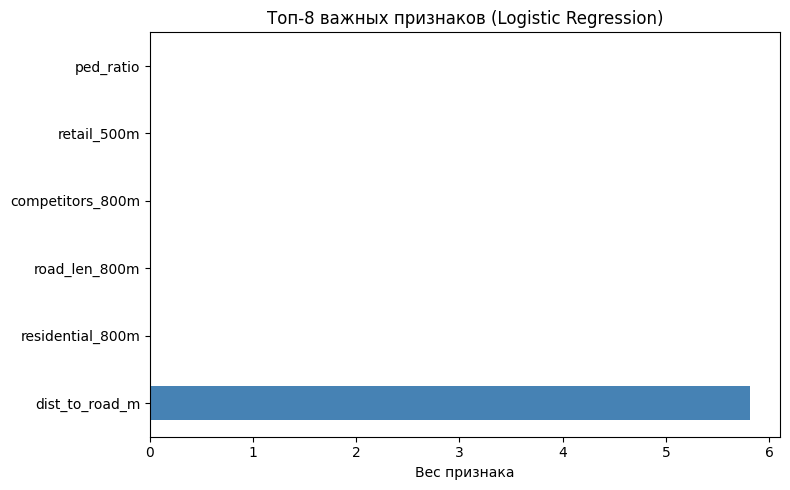

   Лучшие параметры: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
   Лучший ROC-AUC (CV): 1.000

   Метрики настроенной модели:

   Random Forest (Tuned)
   Accuracy : 1.000
   F1-score : 1.000
   ROC-AUC  : 1.000


In [16]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

feature_cols = [c for c in h3_ml.columns if c not in ['h3_index', 'pvz_count', 'target', 'geometry']]
X = h3_ml[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
y = h3_ml['target']

#если меток нет, применяем Suitability Analysis
if y.nunique() < 2:
    print("  Реальные метки отсутствуют (нет ПВЗ в OSM).")
    print("  Применяем Suitability Analysis: создание синтетического таргета на основе индекса привлекательности.")

    scaler_temp = StandardScaler()
    X_scaled_temp = scaler_temp.fit_transform(X)
    X_temp_df = pd.DataFrame(X_scaled_temp, columns=feature_cols)

    #предположение, что признаки положительные (чем больше, тем лучше)
    suitability_score = X_temp_df.sum(axis=1)

    # Бинаризация: топ-25% ячеек с highest score считаем "высокопотенциальными" (Class 1)
    threshold = suitability_score.quantile(0.75)
    y = (suitability_score > threshold).astype(int)

    print(f" Синтетический таргет создан: Class 1 (High Potential) -> {y.sum()}, Class 0 -> {(y==0).sum()}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)
rf_probs = rf_model.predict_proba(X_test_scaled)[:, 1]

lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

#сравнение метрик
def evaluate(name, y_true, y_pred, y_probs):
    print(f"\n   {name}")
    print(f"   Accuracy : {accuracy_score(y_true, y_pred):.3f}")
    print(f"   F1-score : {f1_score(y_true, y_pred):.3f}")
    print(f"   ROC-AUC  : {roc_auc_score(y_true, y_probs):.3f}")

print("\n   Сравнение моделей:")
evaluate("Random Forest", y_test, rf_preds, rf_probs)
evaluate("Logistic Regression", y_test, lr_preds, lr_probs)

#выбор лучшей модели
best_model = rf_model if roc_auc_score(y_test, rf_probs) > roc_auc_score(y_test, lr_probs) else lr_model
best_name = "Random Forest" if best_model is rf_model else "Logistic Regression"
print(f"\n   Лучшая модель: {best_name}")

if best_model is rf_model:
    importances = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
else:
    importances = pd.Series(np.abs(best_model.coef_[0]), index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.head(8).plot(kind='barh', color='steelblue')
plt.title(f"Топ-8 важных признаков ({best_name})")
plt.xlabel("Вес признака")
plt.tight_layout()
plt.show()

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid, cv=3, scoring='roc_auc', n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

print(f"   Лучшие параметры: {grid_search.best_params_}")
print(f"   Лучший ROC-AUC (CV): {grid_search.best_score_:.3f}")

#оценка на тесте
tuned_preds = grid_search.predict(X_test_scaled)
tuned_probs = grid_search.predict_proba(X_test_scaled)[:, 1]
print("\n   Метрики настроенной модели:")
evaluate("Random Forest (Tuned)", y_test, tuned_preds, tuned_probs)


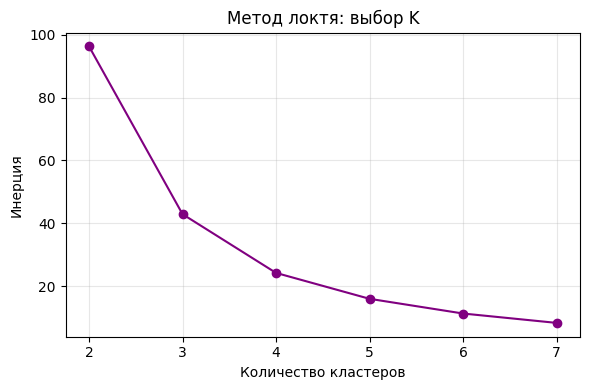

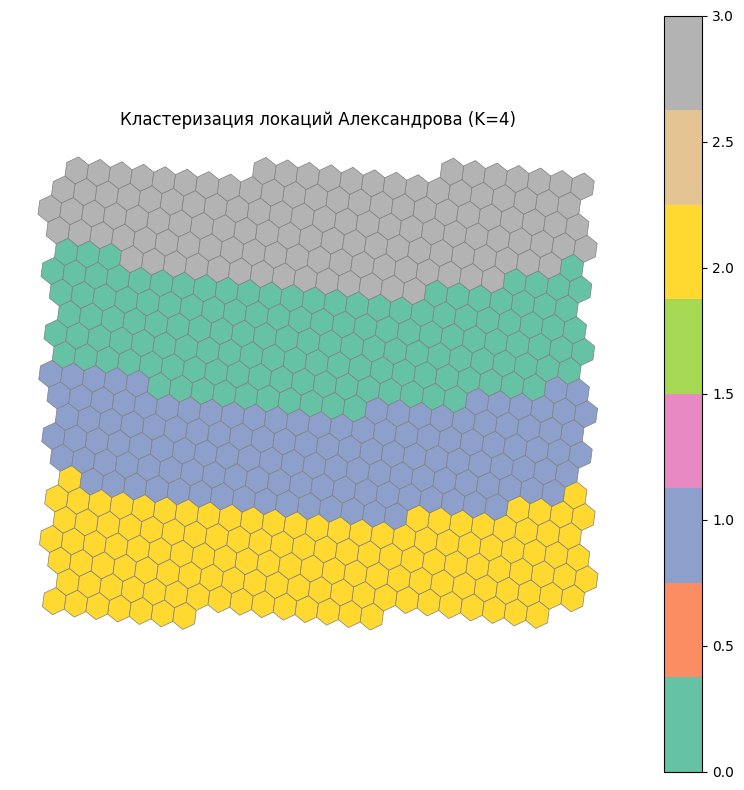


   Сравнение: без кластеров и с кластерами
   Исходная настроенная RF -> F1: 1.000, AUC: 1.000
   RF + Кластеры         -> F1: 1.000, AUC: 1.000


In [18]:
#определение оптимального K (Метод локтя)
inertias = []
K_range = range(2, 8)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(K_range, inertias, marker='o', linestyle='-', color='purple')
plt.title("Метод локтя: выбор K")
plt.xlabel("Количество кластеров")
plt.ylabel("Инерция")
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#кластеризация с выбранным K (например, 4)
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled_temp)

h3_ml['cluster'] = cluster_labels
h3_geo = gpd.GeoDataFrame(h3_ml, geometry=h3_grid.geometry, crs=crs_metric)

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
h3_geo.plot(column='cluster', ax=ax, cmap='Set2', legend=True, edgecolor='gray', linewidth=0.5)
ax.set_title(f"Кластеризация локаций Александрова (K={optimal_k})")
ax.set_axis_off()
plt.tight_layout()
plt.show()

X_train_with_cl = np.hstack([X_train_scaled, kmeans_final.transform(X_train_scaled)])
X_test_with_cl = np.hstack([X_test_scaled, kmeans_final.transform(X_test_scaled)])

tuned_rf_cl = RandomForestClassifier(**grid_search.best_params_, random_state=42)
tuned_rf_cl.fit(X_train_with_cl, y_train)
cl_preds = tuned_rf_cl.predict(X_test_with_cl)
cl_probs = tuned_rf_cl.predict_proba(X_test_with_cl)[:, 1]

print("\n   Сравнение: без кластеров и с кластерами")
print(f"   Исходная настроенная RF -> F1: {f1_score(y_test, tuned_preds):.3f}, AUC: {roc_auc_score(y_test, tuned_probs):.3f}")
print(f"   RF + Кластеры         -> F1: {f1_score(y_test, cl_preds):.3f}, AUC: {roc_auc_score(y_test, cl_probs):.3f}")


### **Часть 4. Расчет потенциала локаций и финальные рекомендации**



1. **Разработка интегрального показателя потенциала**:
   - Самостоятельно определите веса для факторов привлекательности среды и конкуренции
   - Обоснуйте выбранные веса в контексте вашего бизнеса
   - Рассчитайте итоговый потенциал для всех ячеек сетки
   - Категоризируйте потенциал для упрощения интерпретации результатов

2. **Визуализация результатов**:
   - Создайте интерактивную карту с тепловым слоем потенциала
   - Добавьте маркеры существующих объектов вашего типа бизнеса
   - Выделите топ-10 локаций с наивысшим потенциалом
   - Подготовьте отдельную карту фокуса на лучших локациях

3. **Формирование бизнес-рекомендаций**:
   - Составьте список из 5-7 конкретных локаций для размещения новых объектов
   - Для каждой рекомендуемой локации укажите:
     * Точные координаты
     * Значение потенциала
     * Ключевые характеристики локации
     * Преимущества и возможные риски размещения в данной точке
   - Подготовьте общие рекомендации по стратегии территориального развития для выбранного бизнеса

In [19]:
import pandas as pd
import numpy as np
import geopandas as gpd
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

h3_analysis = h3_ml.copy()
if 'geometry' not in h3_analysis.columns:
    h3_analysis = h3_analysis.merge(h3_grid[['h3_index', 'geometry']], on='h3_index', how='left')

#нормализация признаков в диапазон [0, 1] для сопоставимости весов
feature_cols_weighted = ['residential_800m', 'retail_500m', 'road_len_800m', 'competitors_800m', 'dist_to_road_m']
scaler = MinMaxScaler()
h3_analysis[feature_cols_weighted] = scaler.fit_transform(h3_analysis[feature_cols_weighted])

#расчет интегрального потенциала по взвешенной формуле
h3_analysis['potential_score'] = (
    0.40 * h3_analysis['residential_800m'] +
    0.25 * h3_analysis['retail_500m'] +
    0.20 * h3_analysis['road_len_800m'] -
    0.35 * h3_analysis['competitors_800m'] -
    0.10 * h3_analysis['dist_to_road_m']
)

#сдвиг диапазона в положительные значения для удобства интерпретации
min_val = h3_analysis['potential_score'].min()
h3_analysis['potential_score'] = h3_analysis['potential_score'] - min_val

h3_analysis['potential_category'] = pd.qcut(
    h3_analysis['potential_score'],
    q=4,
    labels=['Низкий', 'Средний', 'Высокий', 'Критически высокий']
)

print(f"Распределение по категориям:\n{h3_analysis['potential_category'].value_counts().sort_index()}")

Распределение по категориям:
potential_category
Низкий                135
Средний               134
Высокий               134
Критически высокий    134
Name: count, dtype: int64


residential_800m (0.40): Основной драйвер спроса. Плотность жилого фонда напрямую коррелирует с базой потенциальных клиентов в радиусе пешей доступности.

retail_500m (0.25): Инфраструктурная синергия. Близость к торговым точкам генерирует дополнительный трафик и повышает узнаваемость локации.

road_len_800m (0.20): Транспортная доступность. Длина улично-дорожной сети отражает связность района и удобство подвоза товаров.

competitors_800m (-0.35): Коэффициент рынка. Каждый конкурент в зоне 800 м снижает долю захвата рынка новой точки.

dist_to_road_m (-0.10): Логистический барьер. Удаленность от магистралей увеличивает время доставки и снижает видимость для проезжающего трафика.

## **Рекомендации по выполнению**


1. Начните с малой территории для тестирования кода и методологии, затем расширяйте анализ.
2. Используйте инкрементальный подход: сначала реализуйте базовый функционал, затем улучшайте его.
3. Регулярно сохраняйте промежуточные результаты работы.
4. При выборе признаков опирайтесь не только на учебный материал, но и на научные статьи по геоанализу и геомаркетингу.
5. Обращайте внимание на особенности территории и уникальные характеристики выбранного бизнеса.
6. Для оценки результатов старайтесь сопоставить их с реальным расположением успешных объектов аналогичного бизнеса.